# EmoExpress: End-to-End Pipeline and Streamlit Preparation

## Objective

This notebook integrates the complete EmoExpress workflow:

1. Validate the user's story.
2. Predict emotions using the selected production model.
3. Classify the primary and secondary topics.
4. Retrieve relevant guidance from the PDF knowledge base.
5. Generate a grounded empathetic response and recommendations.
6. Generate an encouraging caption and image prompt.
7. Generate a personalized supportive image.
8. Return all results in one structured output.

The completed pipeline will later be transferred into a Streamlit
application for interactive use.

Import Libraries

In [1]:
from pathlib import Path
from datetime import datetime

import base64
import json
import os
import re
import time

import numpy as np
import pandas as pd
import torch

from dotenv import load_dotenv
from IPython.display import Image, display

from openai import OpenAI

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

C:\Users\Anne\AppData\Local\Temp\ipykernel_36816\4038445430.py:25: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


Configure project paths

In [37]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"

ROBERTA_MODEL_PATH = (MODEL_DIR/ "roberta-goemotions-final")

KNOWLEDGE_BASE_DIR = (PROJECT_ROOT/ "knowledge_base")

VECTOR_STORE_DIR = (PROJECT_ROOT/ "vector_store"/ "chroma_db")

OUTPUT_DIR = PROJECT_ROOT / "outputs"

GENERATED_IMAGE_DIR = (OUTPUT_DIR/ "generated_images")

GENERATED_RESPONSE_DIR = (OUTPUT_DIR/ "generated_responses")

for directory in [GENERATED_IMAGE_DIR,GENERATED_RESPONSE_DIR]:
    directory.mkdir(parents=True,exist_ok=True)

# print("Project root:", PROJECT_ROOT)
# print("Model directory:", MODEL_DIR)
# print("Vector store:", VECTOR_STORE_DIR)

Load OpenAI API key

In [4]:
load_dotenv(PROJECT_ROOT / ".env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY was not found.")

client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI client initialized.")

OpenAI client initialized.


**PART 1: Load the Emotion model**

Using Pretrained RoBERTa

In [5]:
EMOTION_MODEL_NAME = ("SamLowe/roberta-base-go_emotions")

Load the RoBERTa tokenizer and model

In [6]:
emotion_tokenizer = (AutoTokenizer.from_pretrained(EMOTION_MODEL_NAME))

emotion_model = (AutoModelForSequenceClassification.from_pretrained(EMOTION_MODEL_NAME))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

emotion_model.to(device)
emotion_model.eval()

print("Emotion model:", EMOTION_MODEL_NAME)
print("Device:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Emotion model: SamLowe/roberta-base-go_emotions
Device: cpu


Get the emotion labels

In [7]:
id_to_label = emotion_model.config.id2label

emotion_labels = [id_to_label[index] for index in range(len(id_to_label))]

print("Number of emotion labels:", len(emotion_labels))
print(emotion_labels)

Number of emotion labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


Create the emotion prediction function

In [8]:
EMOTION_THRESHOLD = 0.50
MAX_EMOTIONS = 3

In [9]:
def predict_emotions(user_story,
                    tokenizer=emotion_tokenizer,
                    model=emotion_model,
                    threshold=EMOTION_THRESHOLD,
                    maximum_emotions=MAX_EMOTIONS):
    """
    Predict the most relevant emotions from a user story.
    """

    if not isinstance(user_story, str):
        raise TypeError("user_story must be a string.")

    user_story = user_story.strip()

    if not user_story:
        raise ValueError("The user story cannot be empty.")

    encoded_input = tokenizer(user_story,return_tensors="pt",truncation=True,max_length=128,padding=True)

    encoded_input = {key: value.to(device) for key, value in encoded_input.items()}

    with torch.no_grad():
        output = model(**encoded_input)

    probabilities = torch.sigmoid(output.logits)[0].cpu().numpy()

    selected_indices = np.where(probabilities >= threshold)[0]

    if len(selected_indices) == 0:
        selected_indices = np.array([int(np.argmax(probabilities))])

    selected_indices = sorted(selected_indices,key=lambda index: probabilities[index],reverse=True)[:maximum_emotions]

    predictions = [{"emotion": emotion_labels[index],"score": float(probabilities[index])} for index in selected_indices]

    return predictions

In [10]:
predict_emotions("I have another interview tomorrow and feel very nervous.")

[{'emotion': 'nervousness', 'score': 0.6388562917709351}]

**Part 2 — Topic classification**

Define the topic taxonomy

In [11]:
TOPIC_DEFINITIONS = {
    "career_and_work": (
        "Jobs, interviews, unemployment, coworkers, "
        "career decisions, workplace stress, or burnout."
    ),
    "education": (
        "School, exams, assignments, grades, studying, "
        "or academic pressure."
    ),
    "relationships": (
        "Romantic relationships, dating, breakups, trust, "
        "or partner communication."
    ),
    "family": (
        "Parents, children, siblings, marriage, caregiving, "
        "or family conflict."
    ),
    "stress_and_anxiety": (
        "General worry, nervousness, overwhelm, tension, "
        "or anxiety."
    ),
    "grief_and_loss": (
        "Death, bereavement, separation, major loss, "
        "or mourning."
    ),
    "loneliness": (
        "Isolation, lack of connection, or feeling unsupported."
    ),
    "self_confidence": (
        "Self-esteem, self-doubt, insecurity, shame, "
        "or feelings of inadequacy."
    ),
    "financial_concerns": (
        "Bills, debt, budgeting, income, or financial insecurity."
    ),
    "health_and_wellness": (
        "Sleep, exercise, physical health, routines, "
        "or general emotional wellness."
    ),
    "personal_growth": (
        "Goals, motivation, resilience, habits, identity, "
        "or self-improvement."
    ),
    "daily_life": (
        "Ordinary experiences or minor frustrations."
    ),
    "other": (
        "The story does not clearly match another topic."
    ),
}

Create the topic-classification prompt

In [12]:
def format_topic_definitions(topic_definitions):
    return "\n".join(f"- {topic}: {definition}" for topic, definition in topic_definitions.items())

In [13]:
TOPIC_SYSTEM_PROMPT = f"""
You are the topic-classification component of EmoExpress.

Classify the user's story using only these labels:

{format_topic_definitions(TOPIC_DEFINITIONS)}

Rules:

1. Select exactly one primary topic.
2. Select no more than one secondary topic.
3. Use null when no secondary topic is strongly relevant.
4. Do not create new labels.
5. Classify the situation rather than only the emotion.
6. Return valid JSON only.

Required JSON format:

{{
    "primary_topic": "allowed topic",
    "secondary_topic": "allowed topic or null",
    "confidence": 0.0,
    "explanation": "brief explanation"
}}
""".strip()

Create the topic classifier

In [14]:
TOPIC_MODEL = "gpt-4o-mini"

In [15]:
def classify_topic(user_story):
    response = (client.chat.completions.create(model=TOPIC_MODEL,
            temperature=0,
            response_format={"type": "json_object"},
            messages=[{"role": "system","content": (TOPIC_SYSTEM_PROMPT)},
                        {"role": "user","content": ("Classify this story:\n\n" f"{user_story}" )}]))

    result = json.loads(response.choices[0].message.content)

    allowed_topics = set(TOPIC_DEFINITIONS.keys())

    primary_topic = result.get("primary_topic","other")

    secondary_topic = result.get("secondary_topic")

    if primary_topic not in allowed_topics:
        primary_topic = "other"

    if secondary_topic not in allowed_topics:
        secondary_topic = None

    if secondary_topic == primary_topic:
        secondary_topic = None

    return {
        "primary_topic": primary_topic,
        "secondary_topic": secondary_topic,
        "confidence": float(result.get("confidence",0.0)),
        "explanation": str(result.get("explanation",""))}

**Part 3 — Load the RAG vector store**

*Inspect PDF files*

In [38]:
# Find all pdf files
pdf_files = sorted(KNOWLEDGE_BASE_DIR.rglob("*.pdf"))

print("Number of PDF files:",len(pdf_files))

for pdf_path in pdf_files:
    print("-",pdf_path.relative_to(KNOWLEDGE_BASE_DIR),)

Number of PDF files: 80
- career_and_work\burnout_wellbeing.pdf
- career_and_work\manage_stress.pdf
- career_and_work\signs_strategies_burnout.pdf
- career_and_work\stress_finding_job.pdf
- career_and_work\stress_resilience.pdf
- career_and_work\tips_job_search.pdf
- career_and_work\work_life_balance.pdf
- career_and_work\workplace_stress_overview.pdf
- daily_life\digital_wellbeing.pdf
- daily_life\manage_screentime.pdf
- daily_life\sunshine_screentime.pdf
- daily_life\support_digital_wellness.pdf
- daily_life\time_management.pdf
- daily_life\wellness_online.pdf
- education\nature_based_mind_body.pdf
- education\reduce_anxiety.pdf
- education\skill_overcome_anxiety.pdf
- education\test_anxiety_effects.pdf
- education\test_anxiety_medical_students.pdf
- education\tip_for_exam.pdf
- family\family_based_interventions.pdf
- family\parents_caregivers.pdf
- family\parents_youth_mental_health.pdf
- family\positive_parents.pdf
- family\resources.pdf
- family\talking_with_children.pdf
- financi

Initialize embeddings and Chroma

In [16]:
EMBEDDING_MODEL = ("text-embedding-3-small")

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL,api_key=OPENAI_API_KEY)

if not VECTOR_STORE_DIR.exists():
    raise FileNotFoundError("The Chroma database was not found. Run the RAG notebook first.")

vector_store = Chroma(persist_directory=str(VECTOR_STORE_DIR),embedding_function=embeddings)

print("Stored chunks:",vector_store._collection.count())

C:\Users\Anne\AppData\Local\Temp\ipykernel_36816\4091355670.py:8: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(persist_directory=str(VECTOR_STORE_DIR),embedding_function=embeddings)


Stored chunks: 0


Create the retrieval-query function

In [17]:
def build_retrieval_query(user_story,emotion_predictions,topic_result):
    emotion_names = [prediction["emotion"] for prediction in emotion_predictions]

    primary_topic = topic_result["primary_topic"]

    secondary_topic = (topic_result.get("secondary_topic") or "none")

    return f"""
User situation:
{user_story}

Detected emotions:
{", ".join(emotion_names)}

Primary topic:
{primary_topic}

Secondary topic:
{secondary_topic}

Retrieve safe, practical, non-diagnostic guidance,
coping strategies, and constructive next steps
relevant to this situation.
""".strip()

Create the retrieval function

In [18]:
def retrieve_documents(query,primary_topic,k=5):
    primary_results = (vector_store.similarity_search_with_relevance_scores(query=query,k=k,filter={"topic": primary_topic}))

    if primary_results:
        return (primary_results,"primary_topic")

    general_results = (vector_store.similarity_search_with_relevance_scores(query=query,k=k,filter={"topic": "general_support"}))

    if general_results:
        return (general_results,"general_support")

    broad_results = (vector_store.similarity_search_with_relevance_scores(query=query,k=k))

    return (broad_results,"all_topics")

Format the retrieved context

In [19]:
def format_retrieved_context(retrieved_results):
    context_sections = []
    sources = []

    for rank, (document,relevance_score) in enumerate(retrieved_results,start=1):
        title = document.metadata.get("document_title","Unknown document")

        page = document.metadata.get("page_number", "Unknown")

        topic = document.metadata.get("topic","Unknown")

        context_sections.append(f"""
SOURCE {rank}
Title: {title}
Page: {page}
Topic: {topic}

Passage:
{document.page_content}
""".strip())

        sources.append({
                "rank": rank,
                "title": title,
                "page": page,
                "topic": topic,
                "source_file": (document.metadata.get("source_file")),
                "relevance_score": float(relevance_score)})

    return ("\n\n".join(context_sections),sources)

**Part 4 — Grounded LLM generation**

Create the response system prompt

In [20]:
RESPONSE_SYSTEM_PROMPT = """
You are EmoExpress, an empathetic emotional-support assistant.

Use the user story, predicted emotions, classified topic, and retrieved
PDF context to provide safe and practical support.

Rules:

1. Do not diagnose medical or mental-health conditions.
2. Do not recommend medication changes.
3. Do not claim to be a therapist or physician.
4. Do not invent citations or page numbers.
5. Use retrieved sources only when they support the recommendation.
6. Keep recommendations practical and manageable.
7. The caption must contain no more than 15 words.
8. The image prompt must represent emotional progress and realistic hope.
9. Do not include graphic distress, violence, self-harm, or medical treatment.
10. Return valid JSON only.

Required JSON format:

{
    "empathetic_response": "string",
    "recommendations": [
        {
            "recommendation": "string",
            "source_title": "string or null",
            "page": "integer or null"
        }
    ],
    "caption": "string",
    "image_prompt": "string",
    "retrieval_status": "grounded, partially_grounded, or not_grounded"
}
""".strip()

Generate the grounded response

In [21]:
RESPONSE_MODEL = "gpt-4o-mini"

In [22]:
def generate_grounded_response(user_story,emotion_predictions,topic_result,retrieved_context,retrieved_sources):
    prompt = f"""
USER STORY

{user_story}

EMOTION PREDICTIONS

{json.dumps(
    emotion_predictions,
    indent=2
)}

TOPIC CLASSIFICATION

{json.dumps(
    topic_result,
    indent=2
)}

RETRIEVED KNOWLEDGE

{retrieved_context}

AVAILABLE SOURCES

{json.dumps(
    retrieved_sources,
    indent=2
)}

Generate:

1. A short empathetic acknowledgment.
2. Two or three practical recommendations.
3. An encouraging caption.
4. A safe image-generation prompt.

Use citations only when supported by the provided sources.
""".strip()

    response = (
        client.chat.completions.create(
            model=RESPONSE_MODEL,
            temperature=0.3,
            response_format={
                "type": "json_object"
            },
            messages=[
                {
                    "role": "system",
                    "content": (
                        RESPONSE_SYSTEM_PROMPT
                    ),
                },
                {
                    "role": "user",
                    "content": prompt,
                },
            ],
        )
    )

    return json.loads(
        response
        .choices[0]
        .message
        .content
    )

**Part 5 — Image generation**

Create the prompt-enhancement helper

In [23]:
def prepare_image_prompt(image_prompt):
    return f"""
{image_prompt}

Create a polished and emotionally supportive digital illustration.

Requirements:

- Show symbolic emotional progress and realistic hope.
- Avoid depicting a specific identifiable person.
- Use a calm and balanced composition.
- Do not include text, logos, watermarks, or interface elements.
- Do not depict self-harm, violence, medication, or graphic distress.
""".strip()

Create a filename helper

In [24]:
def create_safe_filename(caption):
    safe_caption = re.sub(r"[^a-zA-Z0-9]+","_",caption.lower()).strip("_")

    if not safe_caption:
        safe_caption = "emoexpress_image"

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{safe_caption[:50]}_"
        f"{timestamp}.png"
    )

Create the image-generation function

In [25]:
IMAGE_MODEL = "gpt-image-1"

In [26]:
def generate_image(image_prompt,caption):
    final_prompt = prepare_image_prompt(image_prompt)

    response = client.images.generate(model=IMAGE_MODEL,prompt=final_prompt,size="1024x1024",quality="medium",n=1)

    encoded_image = (response.data[0].b64_json)
    
    image_bytes = base64.b64decode(encoded_image)

    file_name = create_safe_filename(caption)

    image_path = (GENERATED_IMAGE_DIR/ file_name)

    with open(image_path,"wb") as file:
        file.write(image_bytes)

    return {"status": "success",
        "path": str(image_path),
        "model": IMAGE_MODEL,
        "prompt": final_prompt}

Add safe image error handling

In [27]:
def generate_image_safely(image_prompt,caption):
    try:
        return generate_image(image_prompt,caption)

    except Exception as error:
        return {"status": "failed",
            "path": None,
            "model": IMAGE_MODEL,
            "prompt": image_prompt,
            "error": str(error)}

**Part 6 — Complete pipeline**

Create the end-to-end function

In [28]:
def run_emoexpress_pipeline(user_story,retrieval_k=5,generate_image_output=True):
    """
    Run the complete EmoExpress pipeline.
    """

    pipeline_start_time = (time.perf_counter())

    user_story = user_story.strip()

    if len(user_story) < 5:
        raise ValueError("Please enter a more detailed story.")

    emotion_start = time.perf_counter()

    emotion_predictions = (predict_emotions(user_story))

    emotion_time = (time.perf_counter() - emotion_start)

    topic_start = time.perf_counter()

    topic_result = classify_topic(user_story)

    topic_time = (time.perf_counter() - topic_start)

    retrieval_query = (build_retrieval_query(user_story=user_story,emotion_predictions=(emotion_predictions),topic_result=topic_result))

    retrieval_start = (time.perf_counter())

    retrieved_results, strategy = (retrieve_documents(query=retrieval_query,primary_topic=(topic_result["primary_topic"]),k=retrieval_k))

    retrieval_time = (time.perf_counter() - retrieval_start)

    retrieved_context, sources = (format_retrieved_context(retrieved_results))

    if not retrieved_context:
        retrieved_context = ("No directly relevant knowledge-base passages were found.")
        sources = []

    response_start = (time.perf_counter())

    generated_response = (generate_grounded_response(user_story=user_story,emotion_predictions=(emotion_predictions),topic_result=topic_result,
                                                    retrieved_context=(retrieved_context),retrieved_sources= sources ))

    response_time = (time.perf_counter() - response_start)

    image_result = {"status": "skipped","path": None}

    if generate_image_output:
        image_result = (generate_image_safely(image_prompt=(generated_response["image_prompt"]),caption=(generated_response["caption"])))
    
    total_time = (time.perf_counter() - pipeline_start_time)

    return {"user_story": user_story,
        "emotion_predictions": (emotion_predictions),
        "topic_result": topic_result,
        "retrieval": {"query": retrieval_query,"strategy": strategy,"sources": sources},
        "generated_response": (generated_response),
        "generated_image": (image_result),
        "timing": {"emotion_seconds": emotion_time,
            "topic_seconds": topic_time,
            "retrieval_seconds": retrieval_time,
            "response_seconds": response_time,
            "total_seconds": total_time}}

***Test the complete pipeline***

In [29]:
sample_story = """
I have applied to many jobs and attended several interviews,
but I keep getting rejected. I am beginning to lose confidence
and wonder whether I am capable of succeeding.
""".strip()

In [30]:
pipeline_result = (
    run_emoexpress_pipeline(
        user_story=sample_story,
        retrieval_k=5,
        generate_image_output=False,
    )
)

pipeline_result

{'user_story': 'I have applied to many jobs and attended several interviews,\nbut I keep getting rejected. I am beginning to lose confidence\nand wonder whether I am capable of succeeding.',
 'emotion_predictions': [{'emotion': 'disappointment',
   'score': 0.7884987592697144}],
 'topic_result': {'primary_topic': 'career_and_work',
  'secondary_topic': 'self_confidence',
  'confidence': 0.9,
  'explanation': 'The story primarily revolves around job applications and interviews, which falls under career and work. Additionally, the mention of losing confidence relates to self-esteem and self-doubt.'},
 'retrieval': {'query': 'User situation:\nI have applied to many jobs and attended several interviews,\nbut I keep getting rejected. I am beginning to lose confidence\nand wonder whether I am capable of succeeding.\n\nDetected emotions:\ndisappointment\n\nPrimary topic:\ncareer_and_work\n\nSecondary topic:\nself_confidence\n\nRetrieve safe, practical, non-diagnostic guidance,\ncoping strateg

In [31]:
pipeline_result = (
    run_emoexpress_pipeline(
        user_story=sample_story,
        retrieval_k=5,
        generate_image_output=True,
    )
)

Display the result

In [32]:
print("=" * 100)
print("DETECTED EMOTIONS")
print("=" * 100)

for prediction in pipeline_result["emotion_predictions"]:
    print(f"- {prediction['emotion']}: "
          f"{prediction['score']:.4f}")

print("\nPRIMARY TOPIC")

print(pipeline_result["topic_result"]["primary_topic"])

print("\nSECONDARY TOPIC")

print(pipeline_result["topic_result"]["secondary_topic"])

response = pipeline_result["generated_response"]

print("\n" + "=" * 100)
print("EMPATHETIC RESPONSE")
print("=" * 100)

print(response["empathetic_response"])

print("\nRECOMMENDATIONS")

for index, recommendation in enumerate(
    response["recommendations"],start=1):
    print(f"{index}. "
        f"{recommendation['recommendation']}")

    if recommendation.get("source_title"):
        print("   Source:", recommendation[ "source_title" ],
            "| Page:", recommendation.get( "page"))

print("\nCAPTION")

print(response["caption"])

print("\nIMAGE PROMPT")

print(response["image_prompt"])

print("\nSOURCES")

display(pd.DataFrame(pipeline_result["retrieval"]["sources"]))

print("\nTIMING")

display(pd.DataFrame([pipeline_result["timing"]]))

DETECTED EMOTIONS
- disappointment: 0.7885

PRIMARY TOPIC
career_and_work

SECONDARY TOPIC
self_confidence

EMPATHETIC RESPONSE
It's understandable to feel disappointed after facing repeated rejections. You're not alone in this.

RECOMMENDATIONS
1. Consider seeking feedback from your interviews to identify areas for improvement.
2. Try to connect with a mentor or join a job search group for support and encouragement.
3. Focus on your strengths and achievements to rebuild your confidence.

CAPTION
Every setback is a setup for a comeback. Keep pushing forward!

IMAGE PROMPT
A person climbing a mountain, symbolizing perseverance and hope.

SOURCES


""



TIMING


,emotion_seconds,topic_seconds,retrieval_seconds,response_seconds,total_seconds
0,0.092671,1.86902,1.0373,2.798378,21.263332


Display the image when available:

Every setback is a setup for a comeback. Keep pushing forward!


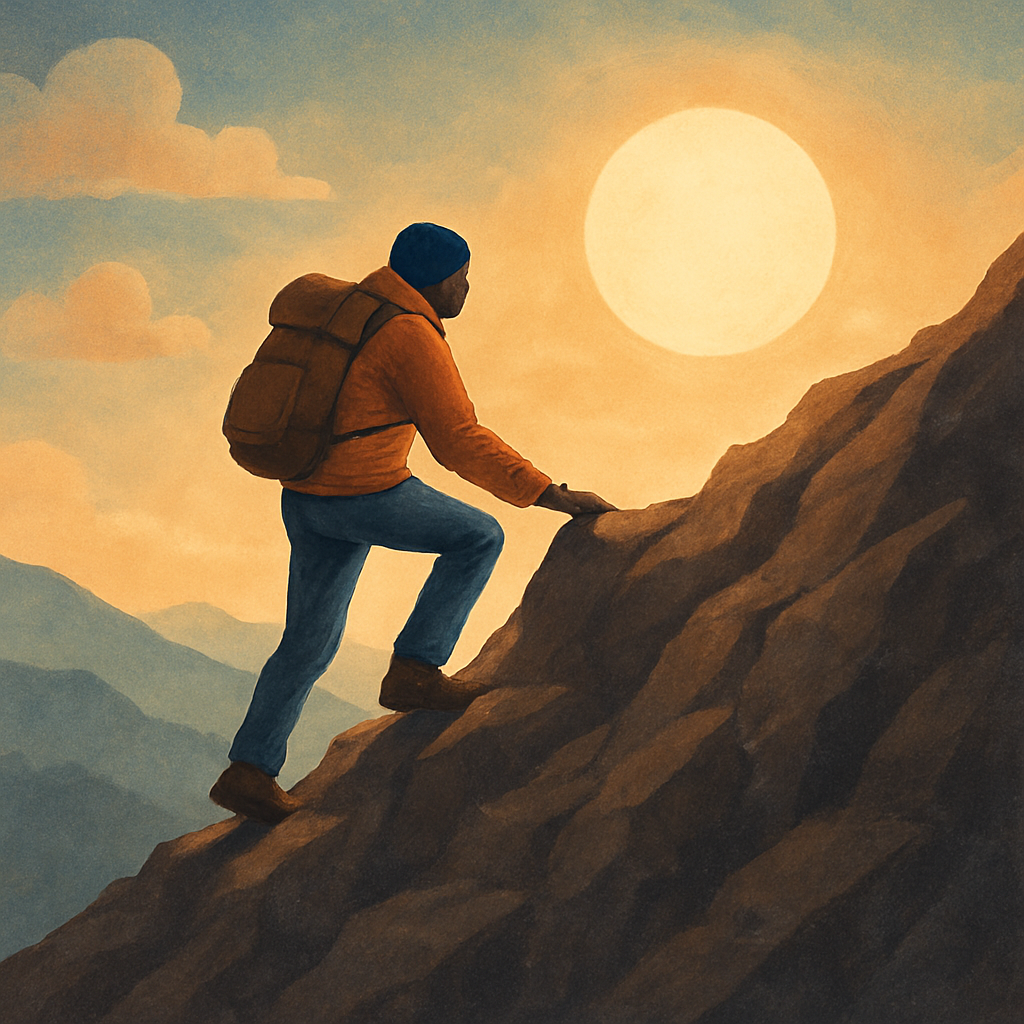

In [33]:
image_path = (pipeline_result["generated_image"].get("path"))

if image_path:
    print(pipeline_result["generated_response"]["caption"])

    display(Image(filename=image_path,width=600))
else:
    print("Image status:",pipeline_result["generated_image"]["status"])

Save the complete result

In [39]:
# Save JSON output
final_output_path = (GENERATED_RESPONSE_DIR/ "complete_pipeline_result.json")

with open(final_output_path,"w",encoding="utf-8") as file:
    json.dump(pipeline_result,file,ensure_ascii=False,indent=4)

print("Saved pipeline result:",final_output_path)

Saved pipeline result: d:\FullStack_Academic\Final Capstone\EmoExpress\outputs\generated_responses\complete_pipeline_result.json


# Conclusion